### Regresion Logistica

In [ ]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

In [ ]:
# Cargar el dataset
try:
    df = pd.read_csv("label_encoding.csv", sep=';')
    print("Dataset cargado")
except FileNotFoundError:
    print("El archivo no se encuentra. Verificar la ruta.")



Dataset cargado


In [ ]:
# Separar features y target
X = df.drop('GRD', axis=1)
y = df['GRD']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Entrenar el modelo de regresión logística
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.3884
Precision: 0.3327
Recall: 0.3884


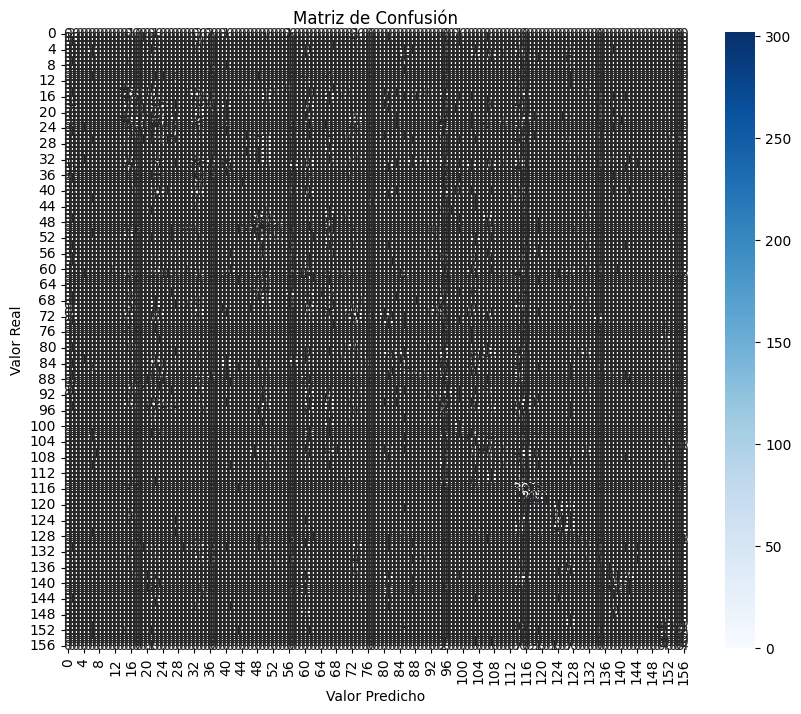

In [ ]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Mostrar matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.show()

In [ ]:
# Calcular AUC general (promedio)
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.unique(y))

# Calcular ROC AUC para cada clase y promediar
roc_auc_macro = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='weighted')
roc_auc_micro = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='micro')

print(f"ROC AUC (macro-average): {roc_auc_macro:.4f}")
print(f"ROC AUC (weighted-average): {roc_auc_weighted:.4f}")
print(f"ROC AUC (micro-average): {roc_auc_micro:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist

ROC AUC (macro-average): nan
ROC AUC (weighted-average): 0.9165
ROC AUC (micro-average): 0.9483


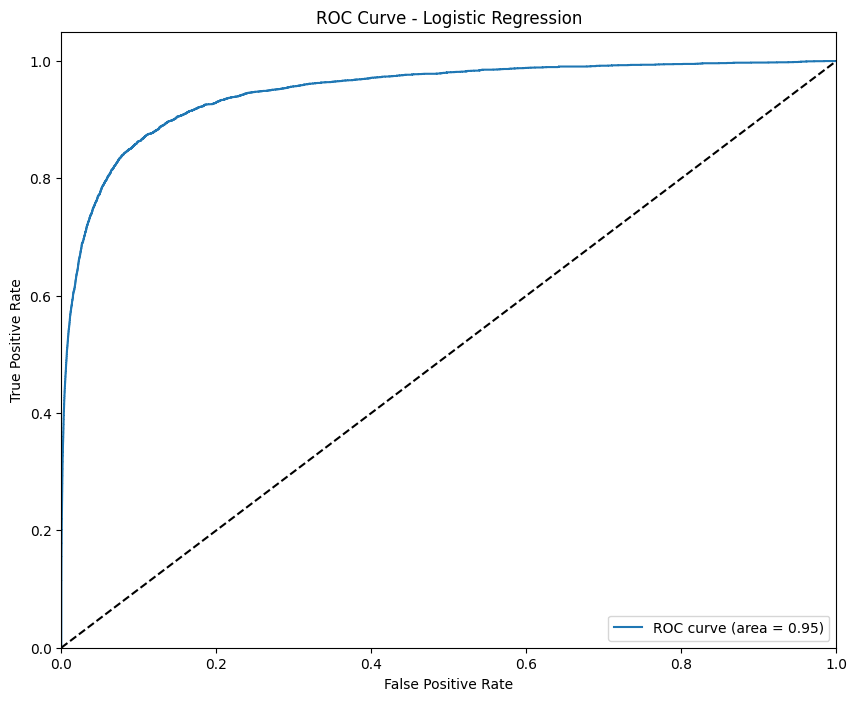

In [ ]:
# Visualizar ROC general (micro-average)
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')  # Traducido a inglés
plt.ylabel('True Positive Rate')   # Traducido a inglés
plt.title('ROC Curve - Logistic Regression')  # Traducido a inglés
plt.legend(loc="lower right")
plt.show()

Resultados de la validación cruzada 5-fold para Regresión Logística:
Puntuaciones individuales: [0.3871936  0.3801901  0.37168584 0.38969485 0.38638639]
Precisión media: 0.3830
Desviación estándar: 0.0065


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


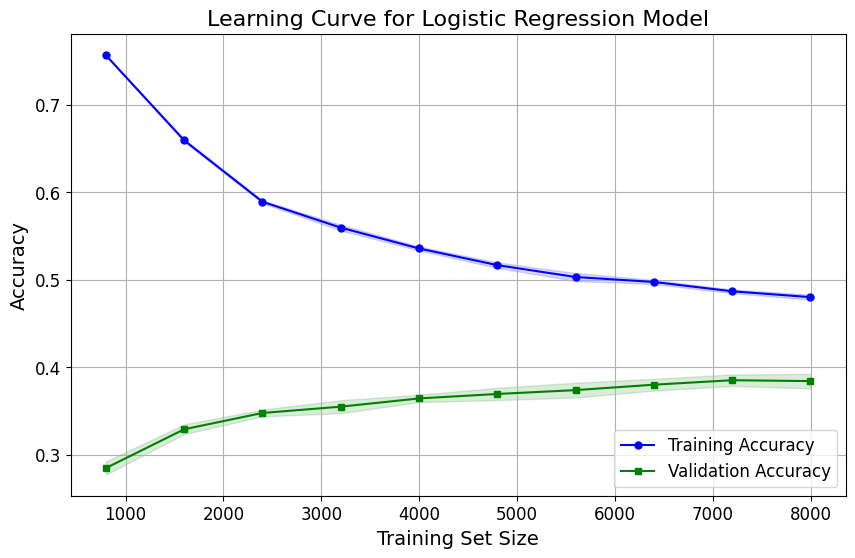

Accuracy final de entrenamiento: 0.4801
Accuracy final de validación: 0.3841
Brecha entre entrenamiento y validación: 0.0960


In [ ]:

# Importar bibliotecas adicionales necesarias
from sklearn.model_selection import cross_val_score, KFold, learning_curve

# Código para la validación cruzada 5-fold
# Crear el modelo de regresión logística con One-vs-Rest para multiclase
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))

# Realizar validación cruzada 5-fold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f"Resultados de la validación cruzada 5-fold para Regresión Logística:")
print(f"Puntuaciones individuales: {cv_scores}")
print(f"Precisión media: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

# Código para la curva de entrenamiento (training vs validation)
# Generar curvas de aprendizaje para Regresión Logística
train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1)

# Calcular media y desviación estándar para las puntuaciones de entrenamiento y validación
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Graficar curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, color='green', marker='s', markersize=5, label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')
plt.title('Learning Curve for Logistic Regression Model', fontsize=16)
plt.xlabel('Training Set Size', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

# Imprimir los valores finales
print(f"Accuracy final de entrenamiento: {train_mean[-1]:.4f}")
print(f"Accuracy final de validación: {val_mean[-1]:.4f}")
print(f"Brecha entre entrenamiento y validación: {train_mean[-1] - val_mean[-1]:.4f}")
